In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay, classification_report, precision_score, recall_score

In [4]:
curve_df = pd.read_hdf('../data/data.h5', key='curve_data')
sample_info = pd.read_hdf('../data/data.h5', key='sample_info')
igi_gene_call = pd.read_hdf('../data/data.h5', key='igi_gene_call')
groundtruth_df = pd.read_csv('../data/groundtruth_df.csv')
groundtruth_df.loc[:,'groundtruth_label'] = groundtruth_df.groundtruth.replace({-1:0, 1:1})
groundtruth_df.loc[:,'encoded_igi_call'] = groundtruth_df.igi_call.replace({'Negative':0, 'Positive':1})

gru_val_pred = pd.read_csv('../data/model_outputs/gru_val_pred_df.csv') #seq_only_val_pred_df.csv')
gru_test_pred = pd.read_csv('../data/model_outputs/gru_test_pred_df.csv') #seq_only_test_pred_df.csv')

test_pred = pd.read_csv('../data/model_outputs/fusion_vit_delta64_test_pred_df.csv')  #ensemble_logis_test_pred.csv')
test_pred = test_pred[test_pred.curve_idx.isin(gru_test_pred.curve_idx)]

retest_pred = pd.read_csv('../data/model_outputs/ensemble_logis_retest_pred.csv')

In [5]:
join_df = (curve_df
           .merge(sample_info, how='inner', on=['well_position','pcr_plate'])
           .merge(igi_gene_call, how ='inner', on=['pcr_plate','sample_id','target']))
           
test_pred_df = (groundtruth_df[['curve_idx','groundtruth_label','encoded_igi_call']].drop_duplicates()
           .merge(test_pred, how='inner', on = 'curve_idx')
           .merge(join_df[['curve_idx','target','sample_id','final_patient_result','current_sample_result','sample_type','record_type','retest_sample_id_1']].drop_duplicates(), 
                  how = 'inner', on = 'curve_idx'))
test_pred_df = test_pred_df.rename(columns={'prob':'outputs'})

retest_pred_df = (retest_pred
                     .merge(join_df[['curve_idx','target','sample_id','final_patient_result','current_sample_result','sample_type','record_type','retest_sample_id_1', 'igi_call']].drop_duplicates(), 
                            how = 'inner', on = 'curve_idx'))
retest_pred_df = retest_pred_df.rename(columns={'prob':'outputs'})
retest_pred_df['groundtruth_label'] = 1*(retest_pred_df.final_patient_result == 'Positive')
retest_pred_df['encoded_igi_call'] = 1*(retest_pred_df.igi_call == 'Positive')
retest_pred_df = retest_pred_df[(retest_pred_df.final_patient_result != 'ReSample') & (~retest_pred_df.target.isin(['MS2','RnaseP']))]

### 10 bins

In [6]:

# Define the number of true negatives and false negatives for different thresholds
# Replace these values with your actual data
thresholds = np.linspace(0.1, 1, 100)
rate_dict = {}
test_pred_df['output_bin'] = pd.cut(test_pred_df.outputs, bins=10, labels = range(10))

for thres in thresholds:
    test_pred_df['pred'] = 1*(test_pred_df.outputs >= thres)
    
    fpr, fnr, fn_se, fp_se = [],[],[],[]
    for i in range(10):
        df = test_pred_df[test_pred_df.output_bin == i]
        try:
            tn, fp, fn, tp = confusion_matrix(df.groundtruth_label, df.pred).ravel()
            fpr.append((fp/(fp+tp)))
            fnr.append(fn/(fn+tn))

            fn_df = df[df.pred == 0]
            fn_pred = 1*(df.groundtruth_label == 1)
            fn_se.append(np.std(fn_pred, ddof=1)/np.sqrt(len(fn_pred)))
            
            fp_df = df[df.pred == 1]
            fp_pred = 1*(df.groundtruth_label == 0)
            fp_se.append(np.std(fp_pred, ddof=1)/np.sqrt(len(fp_pred)))
        except:
            fpr.append(np.nan)
            fnr.append(np.nan)
            fp_se.append(np.nan)
            fn_se.append(np.nan)
        
    rate_dict[thres] = [fpr, fnr, fp_se, fn_se]


igi_fnr, igi_fpr, igi_fp_se, igi_fn_se = [],[],[],[]
for i in range(10):
    df = test_pred_df[test_pred_df.output_bin == i]
    try:
        tn, fp, fn, tp = confusion_matrix(df.groundtruth_label, df.encoded_igi_call).ravel()
        
        df_igi0 = df[df.encoded_igi_call == 0]
        igi_fnr.append(sum(df_igi0.groundtruth_label == 1)/df_igi0.shape[0]) #(np.nan if df_igi0.shape[0] == 0 else df_igi0.shape[0]))
        igi_fn_se.append(np.std(1*(df_igi0.groundtruth_label == 1), ddof=1)/np.sqrt(df_igi0.shape[0]))
        # igi_fn_se.append(1/np.sqrt(df_igi0.shape[0])*np.sqrt(sum((1*(df_igi0.groundtruth_label == 1) - np.mean(1*(df_igi0.groundtruth_label == 1)))**2)/(df_igi0.shape[0] - 1)))

        df_igi1 = df[df.encoded_igi_call == 1]
        igi_fpr.append(sum(df_igi1.groundtruth_label == 0)/(np.nan if df_igi1.shape[0] == 0 else df_igi1.shape[0])) #df_igi1.shape[0])
        igi_fp_se.append(np.std(1*(df_igi1.groundtruth_label == 0), ddof=1)/np.sqrt(df_igi1.shape[0]))
    except:
        igi_fnr.append(np.nan)
        igi_fpr.append(np.nan)
        igi_fn_se.append(np.nan)
        igi_fp_se.append(np.nan)
    


/tmp/ipykernel_3730537/2848313239.py:15: RuntimeWarning: invalid value encountered in scalar divide
  fpr.append((fp/(fp+tp)))
/tmp/ipykernel_3730537/2848313239.py:16: RuntimeWarning: invalid value encountered in scalar divide
  fnr.append(fn/(fn+tn))
/tmp/ipykernel_3730537/2848313239.py:16: RuntimeWarning: invalid value encountered in scalar divide
  fnr.append(fn/(fn+tn))
/tmp/ipykernel_3730537/2848313239.py:16: RuntimeWarning: invalid value encountered in scalar divide
  fnr.append(fn/(fn+tn))
/tmp/ipykernel_3730537/2848313239.py:16: RuntimeWarning: invalid value encountered in scalar divide
  fnr.append(fn/(fn+tn))
/tmp/ipykernel_3730537/2848313239.py:16: RuntimeWarning: invalid value encountered in scalar divide
  fnr.append(fn/(fn+tn))
/tmp/ipykernel_3730537/2848313239.py:16: RuntimeWarning: invalid value encountered in scalar divide
  fnr.append(fn/(fn+tn))
/tmp/ipykernel_3730537/2848313239.py:16: RuntimeWarning: invalid value encountered in scalar divide
  fnr.append(fn/(fn+tn)

/tmp/ipykernel_3730537/2848313239.py:15: RuntimeWarning: invalid value encountered in scalar divide
  fpr.append((fp/(fp+tp)))
/tmp/ipykernel_3730537/2848313239.py:16: RuntimeWarning: invalid value encountered in scalar divide
  fnr.append(fn/(fn+tn))
/tmp/ipykernel_3730537/2848313239.py:16: RuntimeWarning: invalid value encountered in scalar divide
  fnr.append(fn/(fn+tn))
/tmp/ipykernel_3730537/2848313239.py:16: RuntimeWarning: invalid value encountered in scalar divide
  fnr.append(fn/(fn+tn))
/tmp/ipykernel_3730537/2848313239.py:16: RuntimeWarning: invalid value encountered in scalar divide
  fnr.append(fn/(fn+tn))
/tmp/ipykernel_3730537/2848313239.py:16: RuntimeWarning: invalid value encountered in scalar divide
  fnr.append(fn/(fn+tn))
/tmp/ipykernel_3730537/2848313239.py:16: RuntimeWarning: invalid value encountered in scalar divide
  fnr.append(fn/(fn+tn))
/tmp/ipykernel_3730537/2848313239.py:16: RuntimeWarning: invalid value encountered in scalar divide
  fnr.append(fn/(fn+tn)

In [18]:
qualified_fnr = {}
for k in rate_dict.keys():
    for i in range(len(igi_fnr)):
        if rate_dict[k][1][i] < igi_fnr[i]:
            qualified_fnr[k] = i - 1
            next

qualified_thres_10 = []
for ky in qualified_fnr.keys():
    if all(np.isnan(i) | (i <= 0.01) for i in rate_dict[ky][0][qualified_fnr[ky]:]):
        qualified_thres_10.append(ky)

# qualified_thres = list(set(qualified_fnr) & set(qualified_fpr))



#### False Negative Rate

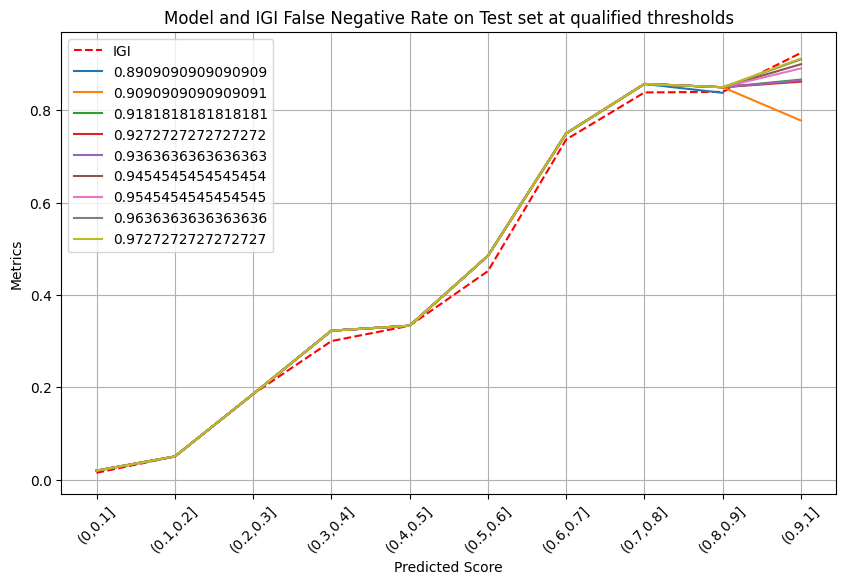

In [29]:

bin_labels = ['(0,0.1]','(0.1,0.2]','(0.2,0.3]','(0.3,0.4]','(0.4,0.5]','(0.5,0.6]','(0.6,0.7]','(0.7,0.8]','(0.8,0.9]','(0.9,1]']

plt.figure(figsize=(10,6))
plt.plot(range(10), igi_fnr, color = 'red', label = 'IGI', linestyle = '--')

for ky in qualified_thres_10:
    plt.plot(range(10), rate_dict[ky][1], label = str(ky))


plt.xticks(ticks=range(10),labels=bin_labels, rotation = 45)
plt.xlabel('Predicted Score')
plt.ylabel('Metrics')
plt.legend()
plt.grid()
plt.title('Model and IGI False Negative Rate on Test set at qualified thresholds')
plt.show()

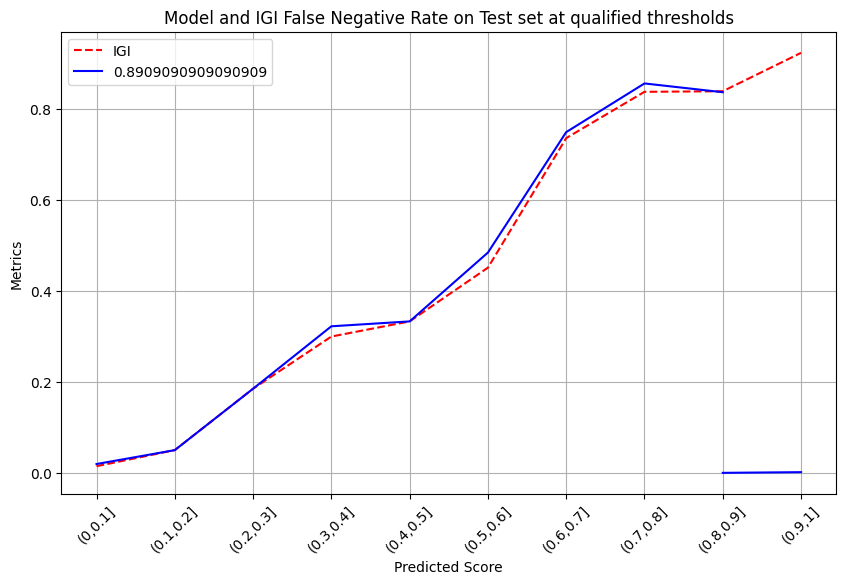

In [ ]:

bin_labels = ['(0,0.1]','(0.1,0.2]','(0.2,0.3]','(0.3,0.4]','(0.4,0.5]','(0.5,0.6]','(0.6,0.7]','(0.7,0.8]','(0.8,0.9]','(0.9,1]']

plt.figure(figsize=(10,6))
plt.plot(range(10), igi_fnr, color = 'red', label = 'IGI', linestyle = '--')

# for ky in qualified_thres_10[0]:
ky = qualified_thres_10[0]
plt.plot(range(10), rate_dict[ky][1], color = 'blue')
plt.plot(range(10), rate_dict[ky][0], color = 'blue', label = str(ky))

plt.xticks(ticks=range(10),labels=bin_labels, rotation = 45)
plt.xlabel('Predicted Score')
plt.ylabel('Metrics')
plt.legend()
plt.grid()
plt.title('Model and IGI False Negative Rate on Test set at qualified thresholds')
plt.show()

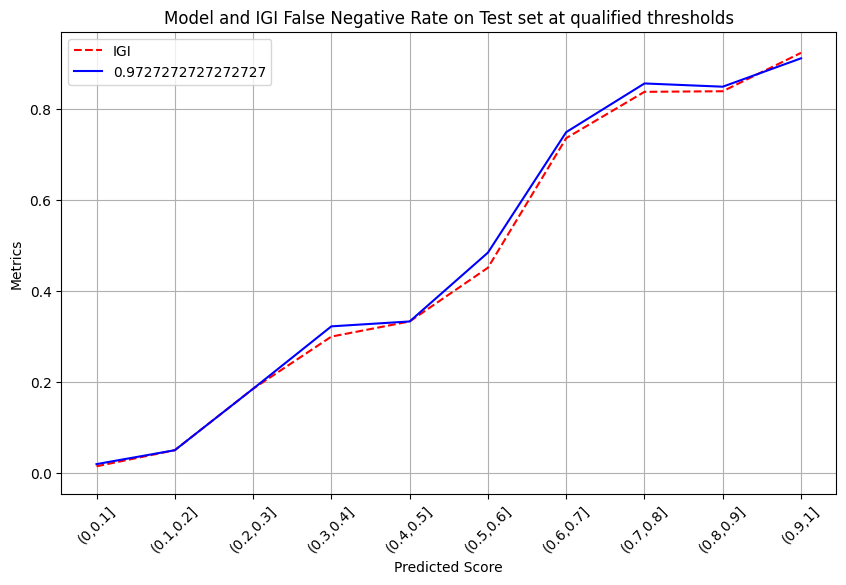

In [31]:

bin_labels = ['(0,0.1]','(0.1,0.2]','(0.2,0.3]','(0.3,0.4]','(0.4,0.5]','(0.5,0.6]','(0.6,0.7]','(0.7,0.8]','(0.8,0.9]','(0.9,1]']

plt.figure(figsize=(10,6))
plt.plot(range(10), igi_fnr, color = 'red', label = 'IGI', linestyle = '--')

# for ky in qualified_thres_10[0]:
ky = qualified_thres_10[len(qualified_thres_10)-1]
plt.plot(range(10), rate_dict[ky][1], color = 'blue')
plt.plot(range(10), rate_dict[ky][0], color = 'blue', label = str(ky))

plt.xticks(ticks=range(10),labels=bin_labels, rotation = 45)
plt.xlabel('Predicted Score')
plt.ylabel('Metrics')
plt.legend()
plt.grid()
plt.title('Model and IGI False Negative Rate on Test set at qualified thresholds')
plt.show()

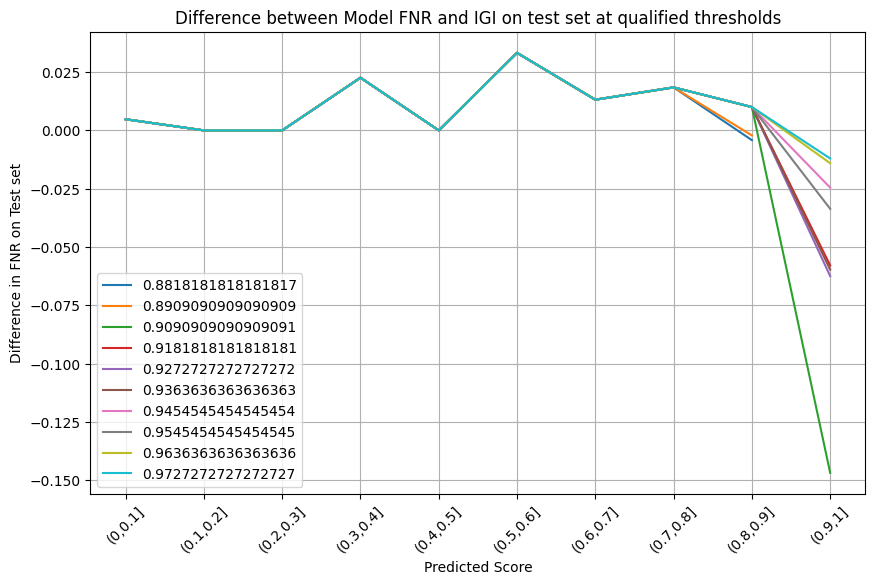

In [23]:
plt.figure(figsize=(10,6))

for ky in qualified_thres_10:
    plt.plot(range(10), [a - b for a,b in zip(rate_dict[ky][1], igi_fnr)], label = str(ky))


plt.xticks(ticks=range(10),labels=bin_labels, rotation = 45)
plt.xlabel('Predicted Score')
plt.ylabel('Difference in FNR on Test set')
plt.legend()
plt.grid()
plt.title('Difference between Model FNR and IGI on test set at qualified thresholds')
plt.show()

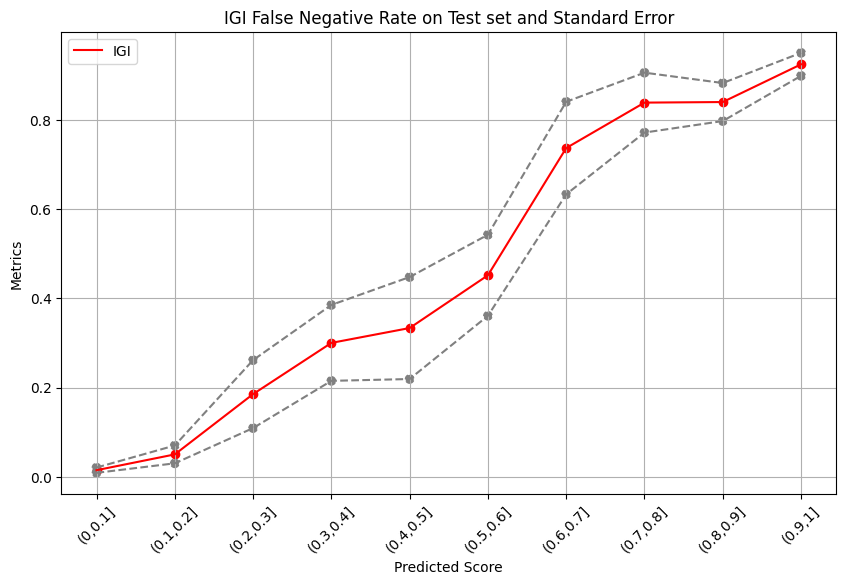

In [11]:

plt.figure(figsize=(10,6))
plt.plot(range(10), igi_fnr, color = 'red', label = 'IGI')
plt.plot(range(10), [a+b for a,b in zip(igi_fnr, igi_fn_se)], color = 'gray', linestyle='--')
plt.plot(range(10), [a-b for a,b in zip(igi_fnr, igi_fn_se)], color = 'gray', linestyle='--')
plt.scatter(range(10), igi_fnr, color = 'red')
plt.scatter(range(10), [a+b for a,b in zip(igi_fnr, igi_fn_se)], color = 'gray', linestyle='--')
plt.scatter(range(10), [a-b for a,b in zip(igi_fnr, igi_fn_se)], color = 'gray', linestyle='--')

plt.xticks(ticks=range(10),labels=bin_labels, rotation = 45)
plt.xlabel('Predicted Score')
plt.ylabel('Metrics')
plt.legend()
plt.grid()
plt.title('IGI False Negative Rate on Test set and Standard Error')
plt.show()

In [12]:
pd.DataFrame({'x_labels': bin_labels,
             'n': test_pred_df.groupby('output_bin').curve_idx.nunique(),
             'n_igi0': test_pred_df[test_pred_df.encoded_igi_call == 0].groupby('output_bin').curve_idx.nunique(),
             'n_gt1': test_pred_df[test_pred_df.groundtruth_label == 1].groupby('output_bin').curve_idx.nunique(),
             'n_gt1_igi0': test_pred_df[(test_pred_df.groundtruth_label == 1) & (test_pred_df.encoded_igi_call == 0)].groupby('output_bin').curve_idx.nunique()
             }).reset_index(drop=True)

/tmp/ipykernel_3730537/834720918.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  'n': test_pred_df.groupby('output_bin').curve_idx.nunique(),
/tmp/ipykernel_3730537/834720918.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  'n_igi0': test_pred_df[test_pred_df.encoded_igi_call == 0].groupby('output_bin').curve_idx.nunique(),
/tmp/ipykernel_3730537/834720918.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  'n_gt1

,x_labels,n,n_igi0,n_gt1,n_gt1_igi0
0,"(0,0.1]",413,411,8,6
1,"(0.1,0.2]",120,120,6,6
2,"(0.2,0.3]",27,27,5,5
3,"(0.3,0.4]",31,30,10,9
4,"(0.4,0.5]",18,18,6,6
5,"(0.5,0.6]",33,31,16,14
6,"(0.6,0.7]",20,19,15,14
7,"(0.7,0.8]",35,31,30,26
8,"(0.8,0.9]",80,75,68,63
9,"(0.9,1]",5367,106,5359,98


#### False Positive Rate

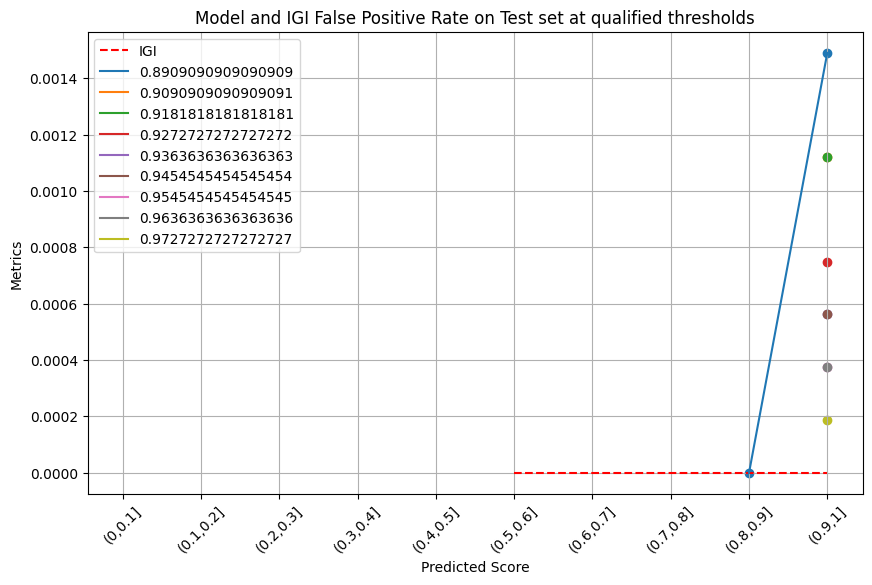

In [13]:

plt.figure(figsize=(10,6))
plt.plot(range(10), igi_fpr, color = 'red', linestyle = '--', label = 'IGI')

for ky in qualified_thres_10: 
    plt.plot(range(10), rate_dict[ky][0], label = str(ky))
    plt.scatter(range(10), rate_dict[ky][0])


plt.xticks(ticks=range(10),labels=bin_labels, rotation = 45)
plt.xlabel('Predicted Score')
plt.ylabel('Metrics')
plt.legend()
plt.grid()
plt.title('Model and IGI False Positive Rate on Test set at qualified thresholds')
plt.show()

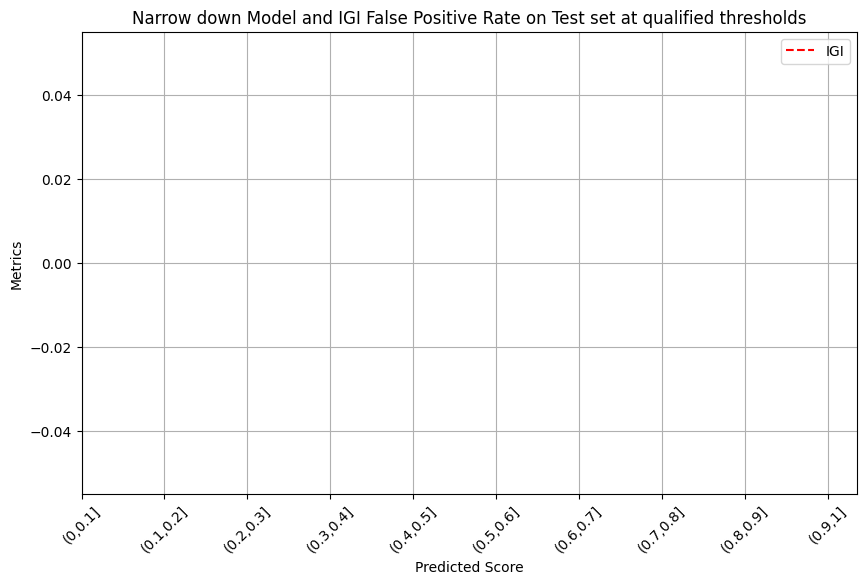

In [24]:

plt.figure(figsize=(10,6))
plt.plot(range(10), igi_fpr, color = 'red', linestyle = '--', label = 'IGI')

for ky in qualified_thres_10[2:]: 
    plt.plot(range(10), rate_dict[ky][0], label = str(ky))
    plt.scatter(range(10), rate_dict[ky][0])


plt.xticks(ticks=range(10),labels=bin_labels, rotation = 45)
plt.xlabel('Predicted Score')
plt.ylabel('Metrics')
plt.legend()
plt.grid()
plt.title('Narrow down Model and IGI False Positive Rate on Test set at qualified thresholds')
plt.show()

In [25]:
pd.DataFrame({'x_labels': bin_labels,
             'n': test_pred_df.groupby('output_bin').curve_idx.nunique(),
             'n_igi1': test_pred_df[test_pred_df.encoded_igi_call == 1].groupby('output_bin').curve_idx.nunique(),
             'n_gt0': test_pred_df[test_pred_df.groundtruth_label == 0].groupby('output_bin').curve_idx.nunique(),
             'n_gt0_igi1': test_pred_df[(test_pred_df.groundtruth_label == 0) & (test_pred_df.encoded_igi_call == 1)].groupby('output_bin').curve_idx.nunique()
             }).reset_index(drop=True)

/tmp/ipykernel_1337620/2663440174.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  'n': test_pred_df.groupby('output_bin').curve_idx.nunique(),
/tmp/ipykernel_1337620/2663440174.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  'n_igi1': test_pred_df[test_pred_df.encoded_igi_call == 1].groupby('output_bin').curve_idx.nunique(),
/tmp/ipykernel_1337620/2663440174.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  'n_

,x_labels,n,n_igi1,n_gt0,n_gt0_igi1
0,"(0,0.1]",531,0,519,0
1,"(0.1,0.2]",0,0,0,0
2,"(0.2,0.3]",29,2,22,0
3,"(0.3,0.4]",30,0,21,0
4,"(0.4,0.5]",31,0,17,0
5,"(0.5,0.6]",18,0,12,0
6,"(0.6,0.7]",19,0,5,0
7,"(0.7,0.8]",0,0,0,0
8,"(0.8,0.9]",106,0,17,0
9,"(0.9,1]",5380,5274,8,0


### 20 bins

In [27]:

# Define the number of true negatives and false negatives for different thresholds
# Replace these values with your actual data

custom_bins = np.linspace(0,0.9,10).tolist()
custom_bins = custom_bins + [0.91, 0.92, 0.93, 0.94, 0.95, 0.96, 0.97, 0.98, 0.99, 1]
test_pred_df['output_bin'] = pd.cut(test_pred_df.outputs, bins=custom_bins, labels = range(19))
bin_labels = pd.cut(test_pred_df.outputs, bins=custom_bins).cat.categories.tolist()

thresholds = np.linspace(0.1, 1, 100)
rate_dict = {}
for thres in thresholds:
    test_pred_df['pred'] = 1*(test_pred_df.outputs >= thres)
    
    fpr, fnr = [],[]
    for i in range(19):
        df = test_pred_df[test_pred_df.output_bin == i]
        try:
            tn, fp, fn, tp = confusion_matrix(df.groundtruth_label, df.pred).ravel()
            fpr.append((fp/(fp+tp)))
            fnr.append(fn/(fn+tn))
        except:
            fpr.append(np.nan)
            fnr.append(np.nan)
        
    rate_dict[thres] = [fpr, fnr]


igi_fnr, igi_fpr, igi_fp_se, igi_fn_se = [],[],[],[]
for i in range(19):
    df = test_pred_df[test_pred_df.output_bin == i]
    try:
        tn, fp, fn, tp = confusion_matrix(df.groundtruth_label, df.encoded_igi_call).ravel()
        
        df_igi0 = df[df.encoded_igi_call == 0]
        igi_fnr.append(sum(df_igi0.groundtruth_label == 1)/df_igi0.shape[0]) #(np.nan if df_igi0.shape[0] == 0 else df_igi0.shape[0]))
        igi_fn_se.append(np.std(1*(df_igi0.groundtruth_label == 1), ddof=1)/np.sqrt(df_igi0.shape[0]))

        df_igi1 = df[df.encoded_igi_call == 1]
        igi_fpr.append(sum(df_igi1.groundtruth_label == 0)/(np.nan if df_igi1.shape[0] == 0 else df_igi1.shape[0])) #df_igi1.shape[0])
        igi_fp_se.append(np.std(1*(df_igi1.groundtruth_label == 0), ddof=1)/np.sqrt(df_igi1.shape[0]))
    except:
        igi_fnr.append(np.nan)
        igi_fpr.append(np.nan)
        igi_fn_se.append(np.nan)
        igi_fp_se.append(np.nan)

# qualified_thres = list(set(qualified_fnr) & set(qualified_fpr))



/tmp/ipykernel_1337620/3677191216.py:19: RuntimeWarning: invalid value encountered in scalar divide
  fpr.append((fp/(fp+tp)))
/tmp/ipykernel_1337620/3677191216.py:20: RuntimeWarning: invalid value encountered in scalar divide
  fnr.append(fn/(fn+tn))
/tmp/ipykernel_1337620/3677191216.py:20: RuntimeWarning: invalid value encountered in scalar divide
  fnr.append(fn/(fn+tn))
/tmp/ipykernel_1337620/3677191216.py:20: RuntimeWarning: invalid value encountered in scalar divide
  fnr.append(fn/(fn+tn))
/tmp/ipykernel_1337620/3677191216.py:20: RuntimeWarning: invalid value encountered in scalar divide
  fnr.append(fn/(fn+tn))
/tmp/ipykernel_1337620/3677191216.py:20: RuntimeWarning: invalid value encountered in scalar divide
  fnr.append(fn/(fn+tn))
/tmp/ipykernel_1337620/3677191216.py:20: RuntimeWarning: invalid value encountered in scalar divide
  fnr.append(fn/(fn+tn))
/tmp/ipykernel_1337620/3677191216.py:20: RuntimeWarning: invalid value encountered in scalar divide
  fnr.append(fn/(fn+tn)

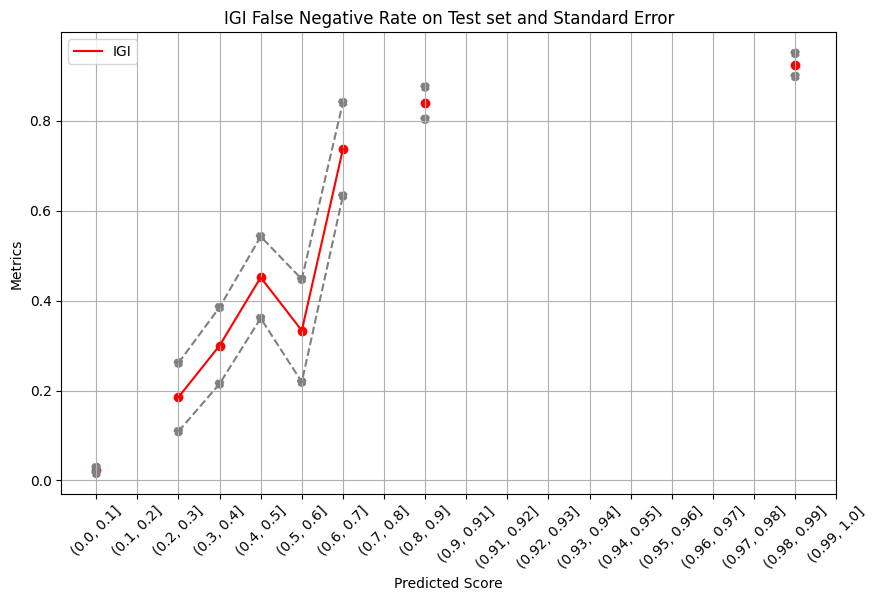

In [29]:

plt.figure(figsize=(10,6))
plt.plot(range(19), igi_fnr, color = 'red', label = 'IGI')
plt.plot(range(19), [a+b for a,b in zip(igi_fnr, igi_fn_se)], color = 'gray', linestyle='--')
plt.plot(range(19), [a-b for a,b in zip(igi_fnr, igi_fn_se)], color = 'gray', linestyle='--')

plt.scatter(range(19), igi_fnr, color = 'red')
plt.scatter(range(19), [a+b for a,b in zip(igi_fnr, igi_fn_se)], color = 'gray', linestyle='--')
plt.scatter(range(19), [a-b for a,b in zip(igi_fnr, igi_fn_se)], color = 'gray', linestyle='--')

plt.xticks(ticks=range(19),labels=bin_labels, rotation = 45)
plt.xlabel('Predicted Score')
plt.ylabel('Metrics')
plt.legend()
plt.grid()
plt.title('IGI False Negative Rate on Test set and Standard Error')
plt.show()

In [30]:
pd.DataFrame({'x_labels': bin_labels,
             'n': test_pred_df.groupby('output_bin').curve_idx.nunique(),
             'n_igi0': test_pred_df[test_pred_df.encoded_igi_call == 0].groupby('output_bin').curve_idx.nunique(),
             'n_gt1': test_pred_df[test_pred_df.groundtruth_label == 1].groupby('output_bin').curve_idx.nunique(),
             'n_gt1_igi0': test_pred_df[(test_pred_df.groundtruth_label == 1) & (test_pred_df.encoded_igi_call == 0)].groupby('output_bin').curve_idx.nunique()
             }).reset_index(drop=True)

/tmp/ipykernel_1337620/834720918.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  'n': test_pred_df.groupby('output_bin').curve_idx.nunique(),
/tmp/ipykernel_1337620/834720918.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  'n_igi0': test_pred_df[test_pred_df.encoded_igi_call == 0].groupby('output_bin').curve_idx.nunique(),
/tmp/ipykernel_1337620/834720918.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  'n_gt1

,x_labels,n,n_igi0,n_gt1,n_gt1_igi0
0,"(0.0, 0.1]",531,531,12,12
1,"(0.1, 0.2]",0,0,0,0
2,"(0.2, 0.3]",29,27,7,5
3,"(0.3, 0.4]",30,30,9,9
4,"(0.4, 0.5]",31,31,14,14
5,"(0.5, 0.6]",18,18,6,6
6,"(0.6, 0.7]",19,19,14,14
7,"(0.7, 0.8]",0,0,0,0
8,"(0.8, 0.9]",106,106,89,89
9,"(0.9, 0.91]",0,0,0,0


In [31]:
    
qualified_fnr = {}
for k in rate_dict.keys():
    for i in range(len(igi_fnr)):
        if rate_dict[k][1][i] < igi_fnr[i]:
            qualified_fnr[k] = i - 1
            next

qualified_thres_20 = []
for ky in qualified_fnr.keys():
    # print(rate_dict[ky][0][qualified_fnr[ky]:])
    if all(np.isnan(i) | (i <= 0.125) for i in rate_dict[ky][0][qualified_fnr[ky]:]):
        qualified_thres_20.append(ky)

#### False Negative Rate

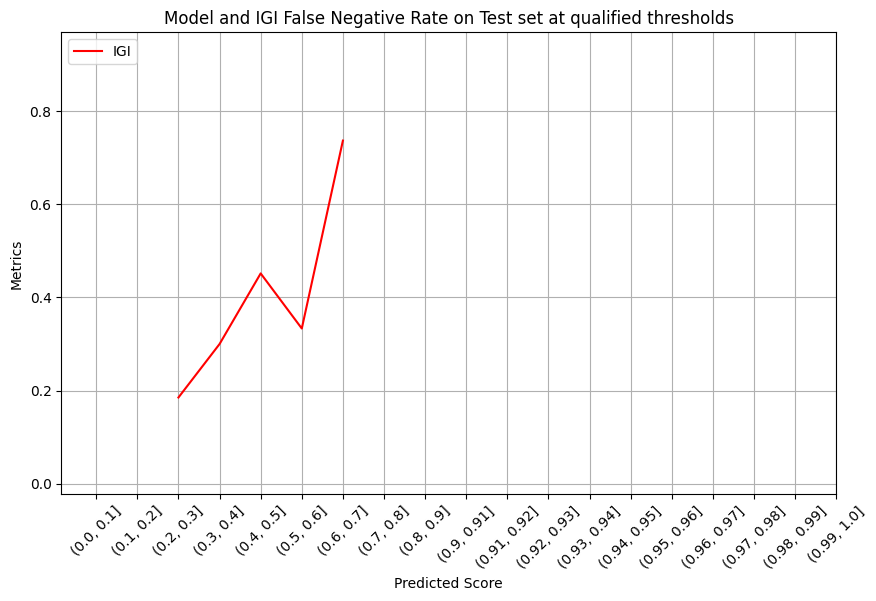

In [32]:

plt.figure(figsize=(10,6))
plt.plot(range(19), igi_fnr, color = 'red', label = 'IGI')

for ky in qualified_thres_20:
    plt.plot(range(19), rate_dict[ky][1], label = str(ky))


plt.xticks(ticks=range(19),labels=bin_labels, rotation = 45)
plt.xlabel('Predicted Score')
plt.ylabel('Metrics')
plt.legend()
plt.grid()
plt.title('Model and IGI False Negative Rate on Test set at qualified thresholds')
plt.show()

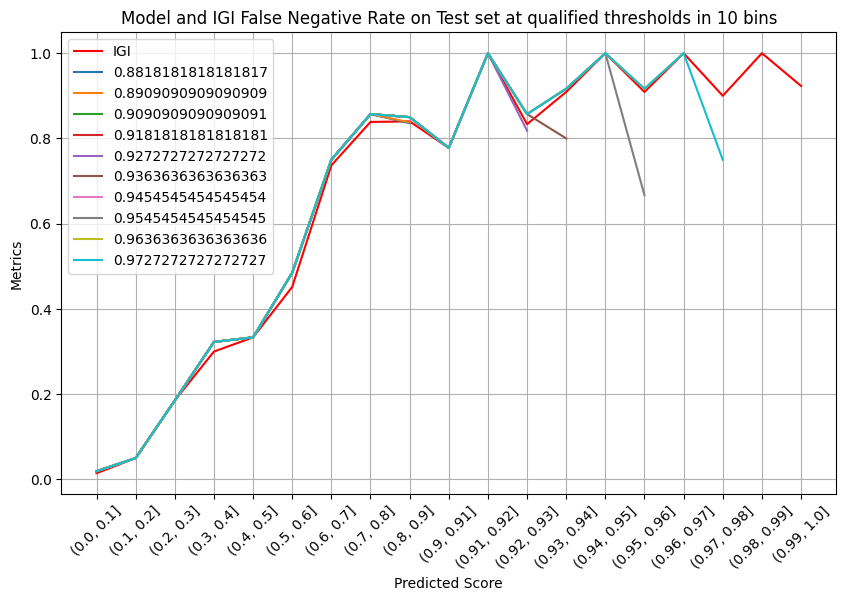

In [82]:

plt.figure(figsize=(10,6))
plt.plot(range(19), igi_fnr, color = 'red', label = 'IGI')

for ky in qualified_thres_10:
    plt.plot(range(19), rate_dict[ky][1], label = str(ky))


plt.xticks(ticks=range(19),labels=bin_labels, rotation = 45)
plt.xlabel('Predicted Score')
plt.ylabel('Metrics')
plt.legend()
plt.grid()
plt.title('Model and IGI False Negative Rate on Test set at qualified thresholds in 10 bins')
plt.show()

#### False Positive Rate

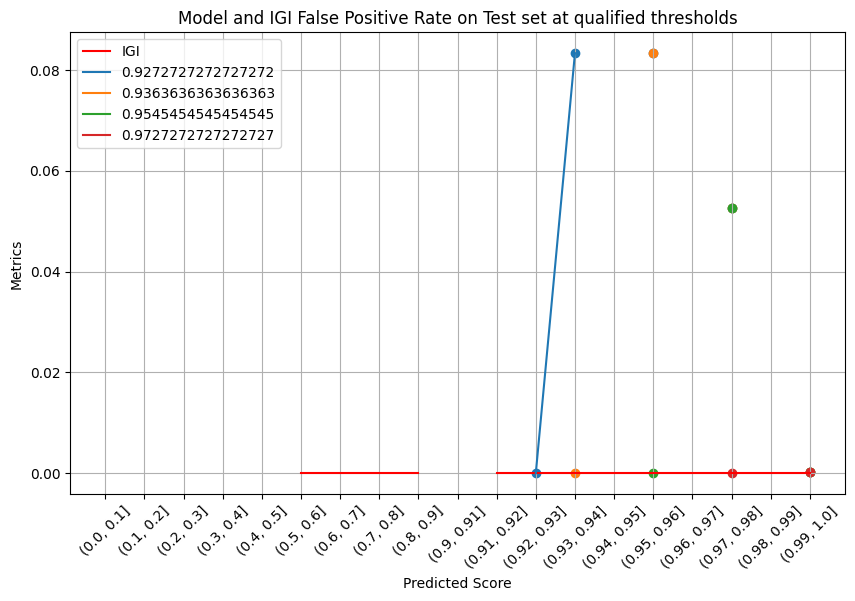

In [69]:

plt.figure(figsize=(10,6))
plt.plot(range(19), igi_fpr, color = 'red', label = 'IGI')

for ky in qualified_thres_20:
    plt.plot(range(19), rate_dict[ky][0], label = str(ky))
    plt.scatter(range(19), rate_dict[ky][0])


plt.xticks(ticks=range(19),labels=bin_labels, rotation = 45)
plt.xlabel('Predicted Score')
plt.ylabel('Metrics')
plt.legend()
plt.grid()
plt.title('Model and IGI False Positive Rate on Test set at qualified thresholds')
plt.show()

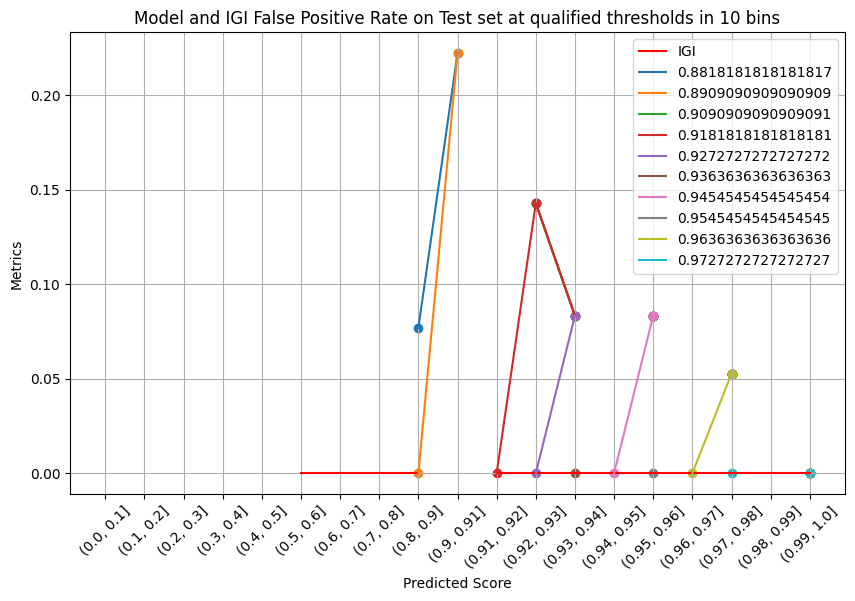

In [70]:

plt.figure(figsize=(10,6))
plt.plot(range(19), igi_fpr, color = 'red', label = 'IGI')

for ky in qualified_thres_10:
    plt.plot(range(19), rate_dict[ky][0], label = str(ky))
    plt.scatter(range(19), rate_dict[ky][0])


plt.xticks(ticks=range(19),labels=bin_labels, rotation = 45)
plt.xlabel('Predicted Score')
plt.ylabel('Metrics')
plt.legend()
plt.grid()
plt.title('Model and IGI False Positive Rate on Test set at qualified thresholds in 10 bins')
plt.show()

#### Predicted Scores Binned for other metrics

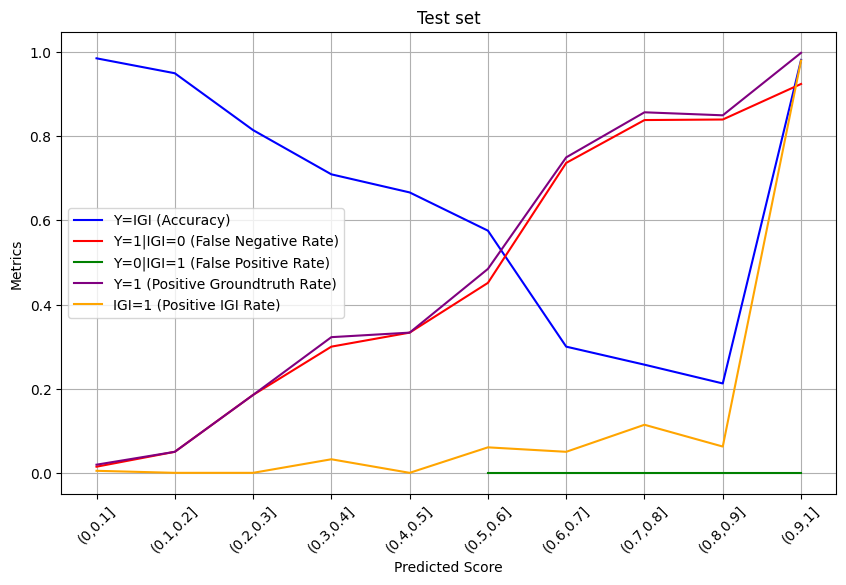

In [5]:
# bin_labels = pd.cut(test_pred_df.outputs, bins=10, include_lowest=True).cat.categories

bin_labels = ['(0,0.1]','(0.1,0.2]','(0.2,0.3]','(0.3,0.4]','(0.4,0.5]','(0.5,0.6]','(0.6,0.7]','(0.7,0.8]','(0.8,0.9]','(0.9,1]']

test_pred_df['output_bin'] = pd.cut(test_pred_df.outputs, bins=10, labels = range(10))


cnt, pos_igi_cnt, neg_igi_cnt, pos_gt_cnt, neg_gt_cnt, acc, fpr, fnr, pr, gt_pr = [],[],[],[],[],[],[],[],[],[]
for i in range(10):
    df = test_pred_df[test_pred_df.output_bin == i]
    tn, fp, fn, tp = confusion_matrix(df.groundtruth_label, df.encoded_igi_call).ravel()
    acc.append((tp+tn)/df.shape[0])
    
    df_igi0 = df[df.encoded_igi_call == 0]
    fnr.append(sum(df_igi0.groundtruth_label == 1)/df_igi0.shape[0]) #(np.nan if df_igi0.shape[0] == 0 else df_igi0.shape[0]))

    df_igi1 = df[df.encoded_igi_call == 1]
    fpr.append(sum(df_igi1.groundtruth_label == 0)/(np.nan if df_igi1.shape[0] == 0 else df_igi1.shape[0])) #df_igi1.shape[0])
    
    pr.append((tp+fp)/df.shape[0])
    gt_pr.append(sum(df.groundtruth_label == 1)/df.shape[0])
    cnt.append(df.shape[0])
    pos_igi_cnt.append(sum(df.encoded_igi_call == 1))
    neg_igi_cnt.append(sum(df.encoded_igi_call == 0))
    pos_gt_cnt.append(sum(df.groundtruth_label == 1))
    neg_gt_cnt.append(sum(df.groundtruth_label == 0))

plt.figure(figsize=(10,6))
plt.plot(range(10), acc, color = 'blue', label = 'Y=IGI (Accuracy)')
plt.plot(range(10), fnr, color = 'red', label = 'Y=1|IGI=0 (False Negative Rate)')
plt.plot(range(10), fpr, color = 'green', label='Y=0|IGI=1 (False Positive Rate)')
plt.plot(range(10), gt_pr, color = 'purple', label='Y=1 (Positive Groundtruth Rate)')
plt.plot(range(10), pr, color = 'orange', label = 'IGI=1 (Positive IGI Rate)')

plt.xticks(ticks=range(10),labels=bin_labels, rotation = 45)
plt.xlabel('Predicted Score')
plt.ylabel('Metrics')
plt.legend()
plt.grid()
plt.title('Test set')
plt.show()


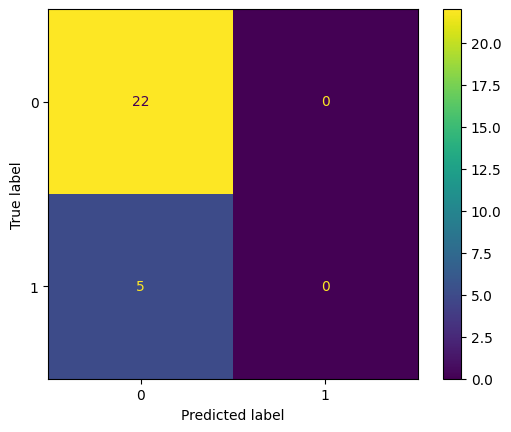

In [8]:
cm = confusion_matrix(df.groundtruth_label, df.encoded_igi_call)
ConfusionMatrixDisplay(cm).plot()

In [5]:
pd.DataFrame({'bin':bin_labels,
                'n_samples': cnt,
                'n_pos_igi': pos_igi_cnt,
                'n_pos_gt': pos_gt_cnt,
                'n_neg_igi': neg_igi_cnt,
                'n_neg_gt': neg_gt_cnt})

,bin,n_samples,n_pos_igi,n_pos_gt,n_neg_igi,n_neg_gt
0,"(0,0.1]",413,2,8,411,405
1,"(0.1,0.2]",120,0,6,120,114
2,"(0.2,0.3]",27,0,5,27,22
3,"(0.3,0.4]",31,1,10,30,21
4,"(0.4,0.5]",18,0,6,18,12
5,"(0.5,0.6]",33,2,16,31,17
6,"(0.6,0.7]",20,1,15,19,5
7,"(0.7,0.8]",35,4,30,31,5
8,"(0.8,0.9]",80,5,68,75,12
9,"(0.9,1]",5367,5261,5359,106,8


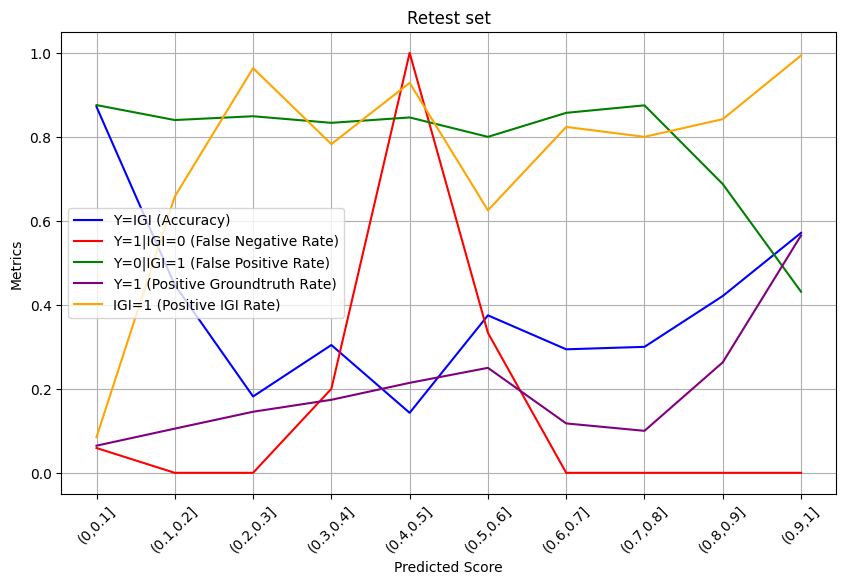

In [6]:
# bin_labels = pd.cut(test_pred_df.outputs, bins=10, include_lowest=True).cat.categories

bin_labels = ['(0,0.1]','(0.1,0.2]','(0.2,0.3]','(0.3,0.4]','(0.4,0.5]','(0.5,0.6]','(0.6,0.7]','(0.7,0.8]','(0.8,0.9]','(0.9,1]']
retest_pred_df['output_bin'] = pd.cut(retest_pred_df.outputs, bins=10, labels = range(10))

cnt, pos_igi_cnt, neg_igi_cnt, pos_gt_cnt, neg_gt_cnt, acc, fpr, fnr, pr, gt_pr = [],[],[],[],[],[],[],[],[],[]
for i in range(10):
    df = retest_pred_df[retest_pred_df.output_bin == i]
    tn, fp, fn, tp = confusion_matrix(df.groundtruth_label, df.encoded_igi_call).ravel()
    acc.append((tp+tn)/df.shape[0])
    fpr.append((fp/(fp+tp)))
    fnr.append(fn/(fn+tn))
    # fnr.append(df[(df.encoded_igi_call == 0) & (df.groundtruth_label == 1)].shape[0]/df[df.encoded_igi_call ==0].shape[0])
    pr.append((tp+fp)/df.shape[0])
    gt_pr.append(sum(df.groundtruth_label == 1)/df.shape[0])
    cnt.append(df.shape[0])
    pos_igi_cnt.append(sum(df.encoded_igi_call == 1))
    neg_igi_cnt.append(sum(df.encoded_igi_call == 0))
    pos_gt_cnt.append(sum(df.groundtruth_label == 1))
    neg_gt_cnt.append(sum(df.groundtruth_label == 0))

plt.figure(figsize=(10,6))
plt.plot(range(10), acc, color = 'blue', label = 'Y=IGI (Accuracy)')
plt.plot(range(10), fnr, color = 'red', label = 'Y=1|IGI=0 (False Negative Rate)')
plt.plot(range(10), fpr, color = 'green', label='Y=0|IGI=1 (False Positive Rate)')
plt.plot(range(10), gt_pr, color = 'purple', label='Y=1 (Positive Groundtruth Rate)')
plt.plot(range(10), pr, color = 'orange', label = 'IGI=1 (Positive IGI Rate)')

plt.xticks(ticks=range(10),labels=bin_labels, rotation = 45)
plt.xlabel('Predicted Score')
plt.ylabel('Metrics')
plt.legend()
plt.grid()
plt.title('Retest set')
plt.show()


In [7]:
pd.DataFrame({'bin':bin_labels,
                'n_samples': cnt,
                'n_pos_igi': pos_igi_cnt,
                'n_pos_gt': pos_gt_cnt,
                'n_neg_igi': neg_igi_cnt,
                'n_neg_gt': neg_gt_cnt})

,bin,n_samples,n_pos_igi,n_pos_gt,n_neg_igi,n_neg_gt
0,"(0,0.1]",2366,201,153,2165,2213
1,"(0.1,0.2]",76,50,8,26,68
2,"(0.2,0.3]",55,53,8,2,47
3,"(0.3,0.4]",23,18,4,5,19
4,"(0.4,0.5]",14,13,3,1,11
5,"(0.5,0.6]",8,5,2,3,6
6,"(0.6,0.7]",17,14,2,3,15
7,"(0.7,0.8]",10,8,1,2,9
8,"(0.8,0.9]",19,16,5,3,14
9,"(0.9,1]",161,160,91,1,70


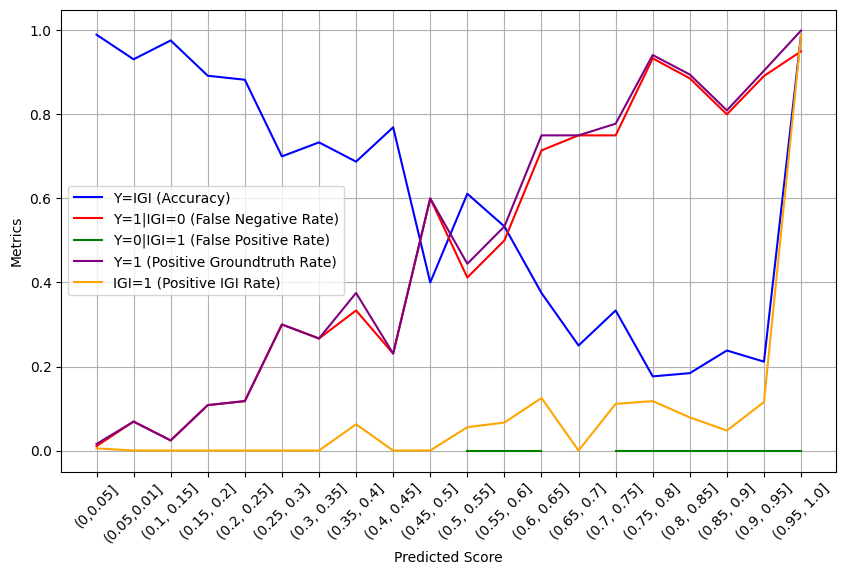

In [8]:
bin_labels = pd.cut(test_pred_df.outputs, bins=20, include_lowest=True).cat.categories.astype('str').to_list()
bin_labels[0] = '(0,0.05]'
bin_labels[1] = '(0.05,0.01]'

# bin_labels = ['(0,0.1]','(0.1,0.2]','(0.2,0.3]','(0.3,0.4]','(0.4,0.5]','(0.5,0.6]','(0.6,0.7]','(0.7,0.8]','(0.8,0.9]','(0.9,1]']
test_pred_df['output_bin'] = pd.cut(test_pred_df.outputs, bins=20, labels = range(20))

cnt, pos_igi_cnt, neg_igi_cnt, pos_gt_cnt, neg_gt_cnt, acc, fpr, fnr, pr, gt_pr = [],[],[],[],[],[],[],[],[],[]
for i in range(20):
    df = test_pred_df[test_pred_df.output_bin == i]
    tn, fp, fn, tp = confusion_matrix(df.groundtruth_label, df.encoded_igi_call).ravel()
    acc.append((tp+tn)/df.shape[0])

    df_igi0 = df[df.encoded_igi_call == 0]
    fnr.append(sum(df_igi0.groundtruth_label == 1)/df_igi0.shape[0])

    df_igi1 = df[df.encoded_igi_call == 1]
    fpr.append(sum(df_igi1.groundtruth_label == 0)/(np.nan if df_igi1.shape[0] == 0 else df_igi1.shape[0])) #df_igi1.shape[0])

    pr.append((tp+fp)/df.shape[0])
    gt_pr.append(sum(df.groundtruth_label == 1)/df.shape[0])
    
    cnt.append(df.shape[0])
    pos_igi_cnt.append(sum(df.encoded_igi_call == 1))
    neg_igi_cnt.append(sum(df.encoded_igi_call == 0))
    pos_gt_cnt.append(sum(df.groundtruth_label == 1))
    neg_gt_cnt.append(sum(df.groundtruth_label == 0))

plt.figure(figsize=(10,6))
plt.plot(range(20), acc, color = 'blue', label = 'Y=IGI (Accuracy)')
plt.plot(range(20), fnr, color = 'red', label = 'Y=1|IGI=0 (False Negative Rate)')
plt.plot(range(20), fpr, color = 'green', label='Y=0|IGI=1 (False Positive Rate)')
plt.plot(range(20), gt_pr, color = 'purple', label='Y=1 (Positive Groundtruth Rate)')
plt.plot(range(20), pr, color = 'orange', label = 'IGI=1 (Positive IGI Rate)')

plt.xticks(ticks=range(20),labels=bin_labels, rotation = 45)
plt.xlabel('Predicted Score')
plt.ylabel('Metrics')
plt.legend()
plt.grid()
plt.show()


In [9]:
pd.DataFrame({'bin':bin_labels,
                'n_samples': cnt,
                'n_pos_igi': pos_igi_cnt,
                'n_pos_gt': pos_gt_cnt,
                'n_neg_igi': neg_igi_cnt,
                'n_neg_gt': neg_gt_cnt})

,bin,n_samples,n_pos_igi,n_pos_gt,n_neg_igi,n_neg_gt
0,"(0,0.05]",384,2,6,382,378
1,"(0.05,0.01]",29,0,2,29,27
2,"(0.1, 0.15]",83,0,2,83,81
3,"(0.15, 0.2]",37,0,4,37,33
4,"(0.2, 0.25]",17,0,2,17,15
5,"(0.25, 0.3]",10,0,3,10,7
6,"(0.3, 0.35]",15,0,4,15,11
7,"(0.35, 0.4]",16,1,6,15,10
8,"(0.4, 0.45]",13,0,3,13,10
9,"(0.45, 0.5]",5,0,3,5,2


/tmp/ipykernel_2159434/154506853.py:13: RuntimeWarning: invalid value encountered in scalar divide
  fnr.append(fn/(fn+tn))
/tmp/ipykernel_2159434/154506853.py:12: RuntimeWarning: invalid value encountered in scalar divide
  fpr.append((fp/(fp+tp)))
/tmp/ipykernel_2159434/154506853.py:13: RuntimeWarning: invalid value encountered in scalar divide
  fnr.append(fn/(fn+tn))
/tmp/ipykernel_2159434/154506853.py:13: RuntimeWarning: invalid value encountered in scalar divide
  fnr.append(fn/(fn+tn))


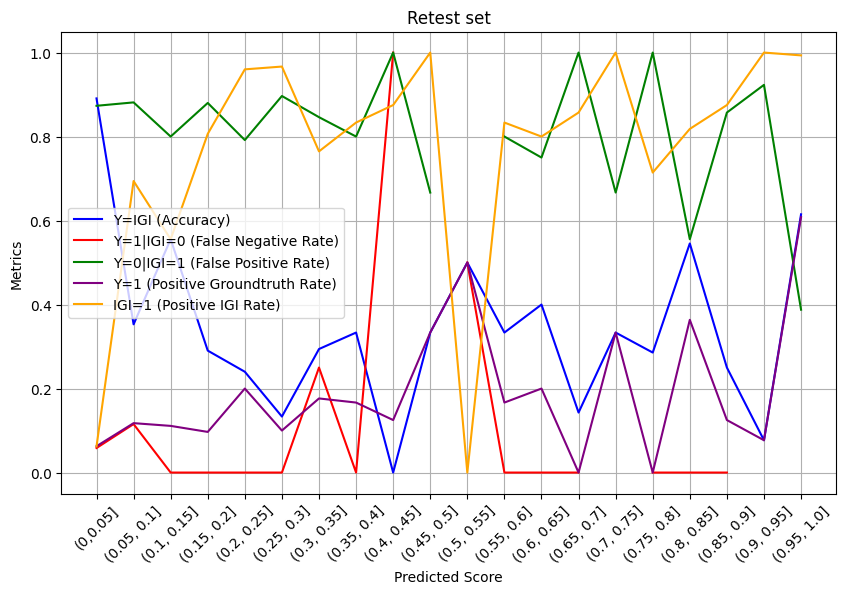

In [10]:
# bin_labels = pd.cut(test_pred_df.outputs, bins=10, include_lowest=True).cat.categories
bin_labels = pd.cut(retest_pred_df.outputs, bins=20, include_lowest=True).cat.categories.astype('str').to_list()
bin_labels[0] = '(0,0.05]'
# bin_labels = ['(0,0.1]','(0.1,0.2]','(0.2,0.3]','(0.3,0.4]','(0.4,0.5]','(0.5,0.6]','(0.6,0.7]','(0.7,0.8]','(0.8,0.9]','(0.9,1]']
retest_pred_df['output_bin'] = pd.cut(retest_pred_df.outputs, bins=20, labels = range(20))

cnt, pos_igi_cnt, neg_igi_cnt, pos_gt_cnt, neg_gt_cnt, acc, fpr, fnr, pr, gt_pr = [],[],[],[],[],[],[],[],[],[]
for i in range(20):
    df = retest_pred_df[retest_pred_df.output_bin == i]
    tn, fp, fn, tp = confusion_matrix(df.groundtruth_label, df.encoded_igi_call).ravel()
    acc.append((tp+tn)/df.shape[0])
    fpr.append((fp/(fp+tp)))
    fnr.append(fn/(fn+tn))
    # fnr.append(df[(df.encoded_igi_call == 0) & (df.groundtruth_label == 1)].shape[0]/df[df.encoded_igi_call ==0].shape[0])
    pr.append((tp+fp)/df.shape[0])
    gt_pr.append(sum(df.groundtruth_label == 1)/df.shape[0])
    cnt.append(df.shape[0])
    pos_igi_cnt.append(sum(df.encoded_igi_call == 1))
    neg_igi_cnt.append(sum(df.encoded_igi_call == 0))
    pos_gt_cnt.append(sum(df.groundtruth_label == 1))
    neg_gt_cnt.append(sum(df.groundtruth_label == 0))

plt.figure(figsize=(10,6))
plt.plot(range(20), acc, color = 'blue', label = 'Y=IGI (Accuracy)')
plt.plot(range(20), fnr, color = 'red', label = 'Y=1|IGI=0 (False Negative Rate)')
plt.plot(range(20), fpr, color = 'green', label='Y=0|IGI=1 (False Positive Rate)')
plt.plot(range(20), gt_pr, color = 'purple', label='Y=1 (Positive Groundtruth Rate)')
plt.plot(range(20), pr, color = 'orange', label = 'IGI=1 (Positive IGI Rate)')

plt.xticks(ticks=range(20),labels=bin_labels, rotation = 45)
plt.xlabel('Predicted Score')
plt.ylabel('Metrics')
plt.legend()
plt.grid()
plt.title('Retest set')
plt.show()


In [11]:
pd.DataFrame({'bin':bin_labels,
                'n_samples': cnt,
                'n_pos_igi': pos_igi_cnt,
                'n_pos_gt': pos_gt_cnt,
                'n_neg_igi': neg_igi_cnt,
                'n_neg_gt': neg_gt_cnt})

,bin,n_samples,n_pos_igi,n_pos_gt,n_neg_igi,n_neg_gt
0,"(0,0.05]",2281,142,143,2139,2138
1,"(0.05, 0.1]",85,59,10,26,75
2,"(0.1, 0.15]",45,25,5,20,40
3,"(0.15, 0.2]",31,25,3,6,28
4,"(0.2, 0.25]",25,24,5,1,20
5,"(0.25, 0.3]",30,29,3,1,27
6,"(0.3, 0.35]",17,13,3,4,14
7,"(0.35, 0.4]",6,5,1,1,5
8,"(0.4, 0.45]",8,7,1,1,7
9,"(0.45, 0.5]",6,6,2,0,4


### Overall Performance

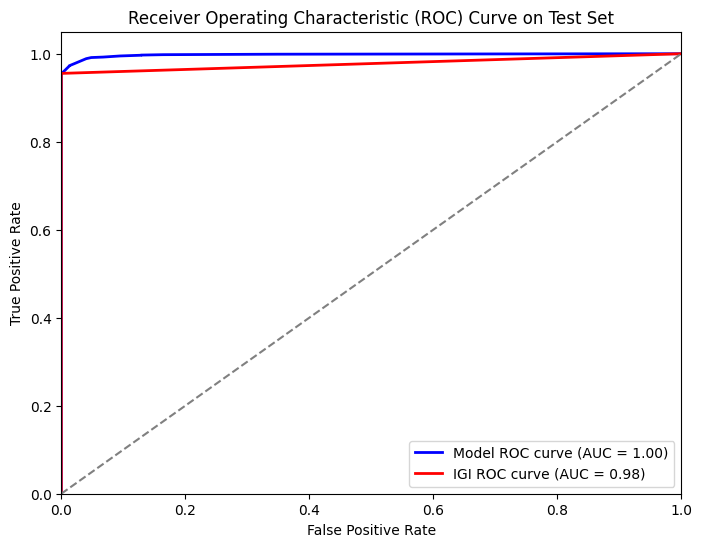

In [38]:
test_auc = roc_auc_score(test_pred_df.groundtruth_label, test_pred_df.outputs)
test_fpr, test_tpr, test_thresholds = roc_curve(test_pred_df.groundtruth_label, test_pred_df.outputs)

test_igi_auc = roc_auc_score(test_pred_df.groundtruth_label, test_pred_df.encoded_igi_call)
test_igi_fpr, test_igi_tpr, test_igi_thresholds = roc_curve(test_pred_df.groundtruth_label, test_pred_df.encoded_igi_call)

plt.figure(figsize=(8, 6))
plt.plot(test_fpr, test_tpr, color='blue', lw=2, label='Model ROC curve (AUC = {:.2f})'.format(test_auc))
plt.plot(test_igi_fpr, test_igi_tpr, color='red', lw=2, label='IGI ROC curve (AUC = {:.2f})'.format(test_igi_auc))
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve on Test Set')
plt.legend(loc='lower right')
plt.show()


In [39]:
tn, fp, fn, tp = confusion_matrix(test_pred_df.groundtruth_label, test_pred_df.encoded_igi_call).ravel()

igi_precision = tp/(fp + tp)
igi_sensitivity = tp/(tp + fn)
igi_specificity = tn/(tn + fp)
igi_f1 = 2*tp/(2*tp + fp + fn)
igi_acc = (tp+tn)/(tp+tn+fp+fn)
igi_neg_pred = sum(test_pred_df.encoded_igi_call == 0)

print('IGI AUC:', test_igi_auc)
print('True negative, false positive, false negative, true positive:', tn, fp, fn, tp)
print('IGI negative predictions:', igi_neg_pred)
print('IGI precision score:', igi_precision)
print('IGI sensitivity score:', igi_sensitivity)
print('IGI specificity:', igi_specificity)
print('IGI F1:', igi_f1)
print('IGI accuracy:', igi_acc)

IGI AUC: 0.9776389643309795
True negative, false positive, false negative, true positive: 621 0 247 5276
IGI negative predictions: 868
IGI precision score: 1.0
IGI sensitivity score: 0.955277928661959
IGI specificity: 1.0
IGI F1: 0.9771275118066488
IGI accuracy: 0.9597981770833334


In [40]:

# Define the number of true negatives and false negatives for different thresholds
# Replace these values with your actual data
thresholds = np.linspace(0.1, 1, 1000)
specificity, precision, accuracy, sensitivity  = [], [], [], []
for thres in thresholds:
    pred = 1*(test_pred_df.outputs >= thres)
    tn, fp, fn, tp = confusion_matrix(test_pred_df.groundtruth_label, pred).ravel()
    
    specificity.append(tn/(tn+fp))
    precision.append(tp/(tp+fp))
    accuracy.append((tp+tn)/len(pred))
    sensitivity.append(tp/(tp+fn))


/tmp/ipykernel_1337620/2478540425.py:10: RuntimeWarning: invalid value encountered in scalar divide
  precision.append(tp/(tp+fp))


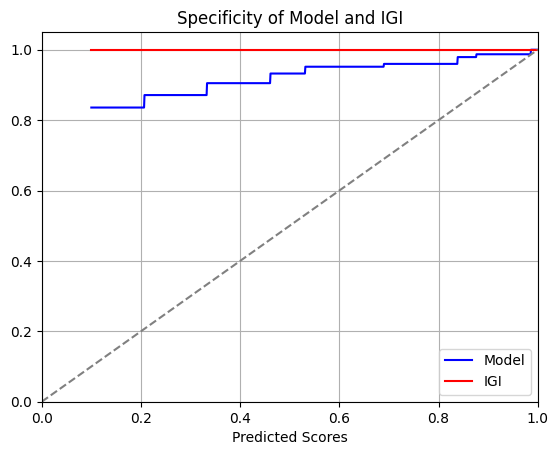

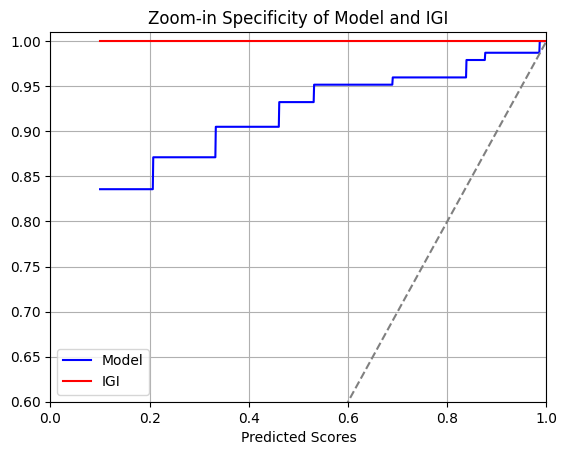

In [41]:
plt.plot(thresholds, specificity, color='blue', label='Model')
plt.plot(thresholds, [igi_specificity]*len(thresholds), color='red', label='IGI')
plt.plot([0,1], [0,1], color='gray', linestyle='--')
plt.xlabel('Predicted Scores')
plt.xlim([0,1])
plt.ylim([0,1.05])
plt.legend()
plt.grid()
plt.title('Specificity of Model and IGI')
plt.show()

plt.plot(thresholds, specificity, color='blue', label='Model')
plt.plot(thresholds, [igi_specificity]*len(thresholds), color='red', label='IGI')
plt.plot([0,1], [0,1], color='gray', linestyle='--')
plt.xlabel('Predicted Scores')
plt.xlim([0,1])
plt.ylim([0.6, 1.01])
plt.legend()
plt.grid()
plt.title('Zoom-in Specificity of Model and IGI')
plt.show()


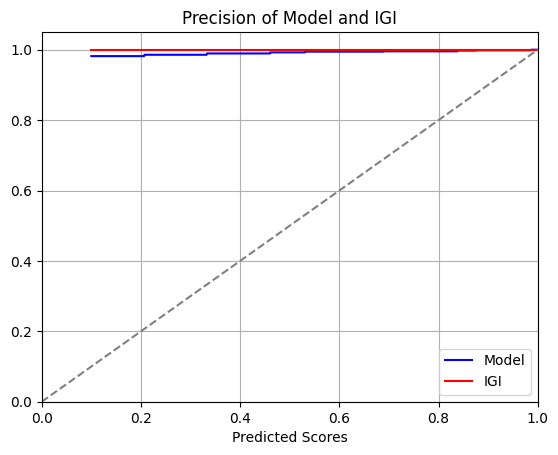

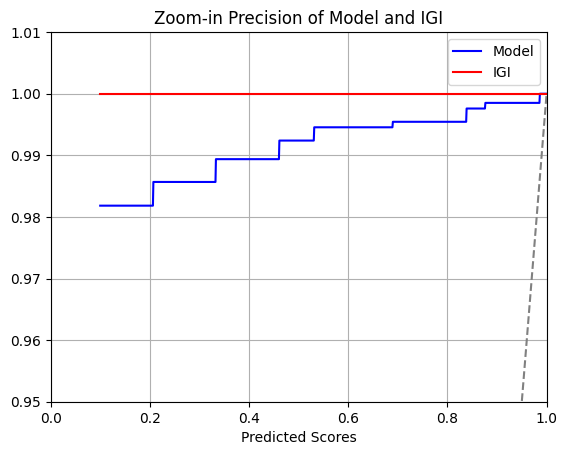

In [42]:
plt.plot(thresholds, precision, color='blue', label='Model')
plt.plot(thresholds, [igi_precision]*len(thresholds), color='red', label='IGI')
plt.plot([0,1], [0,1], color='gray', linestyle='--')
plt.xlabel('Predicted Scores')
plt.xlim([0,1])
plt.ylim([0,1.05])
plt.legend()
plt.grid()
plt.title('Precision of Model and IGI')
plt.show()

plt.plot(thresholds, precision, color='blue', label='Model')
plt.plot(thresholds, [igi_precision]*len(thresholds), color='red', label='IGI')
plt.plot([0,1], [0,1], color='gray', linestyle='--')
plt.xlabel('Predicted Scores')
plt.xlim([0,1])
plt.ylim([0.95, 1.01])
plt.legend()
plt.grid()
plt.title('Zoom-in Precision of Model and IGI')
plt.show()


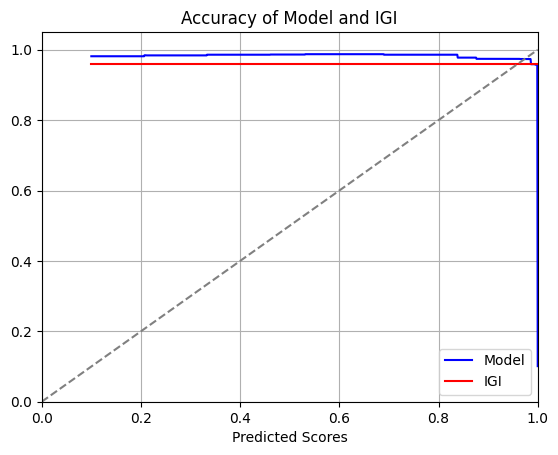

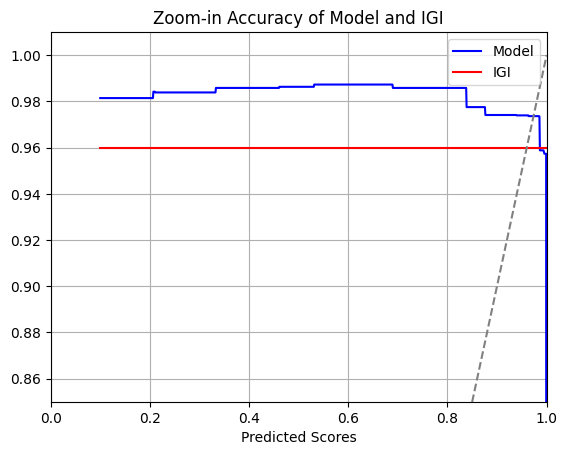

In [43]:
plt.plot(thresholds, accuracy, color='blue', label='Model')
plt.plot(thresholds, [igi_acc]*len(thresholds), color='red', label='IGI')
plt.plot([0,1], [0,1], color='gray', linestyle='--')
plt.xlabel('Predicted Scores')
plt.xlim([0,1])
plt.ylim([0,1.05])
plt.legend()
plt.grid()
plt.title('Accuracy of Model and IGI')
plt.show()

plt.plot(thresholds, accuracy, color='blue', label='Model')
plt.plot(thresholds, [igi_acc]*len(thresholds), color='red', label='IGI')
plt.plot([0,1], [0,1], color='gray', linestyle='--')
plt.xlabel('Predicted Scores')
plt.xlim([0,1])
plt.ylim([0.85, 1.01])
plt.legend()
plt.grid()
plt.title('Zoom-in Accuracy of Model and IGI')
plt.show()


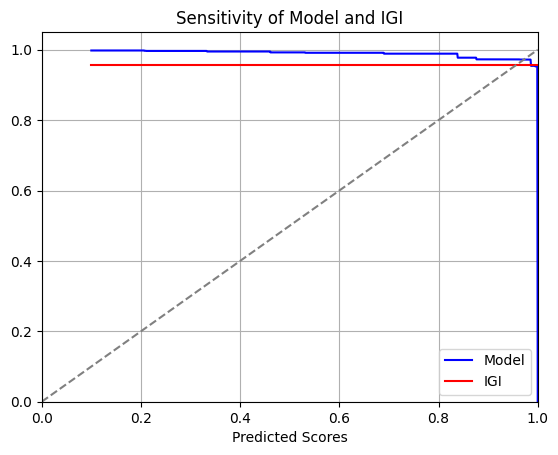

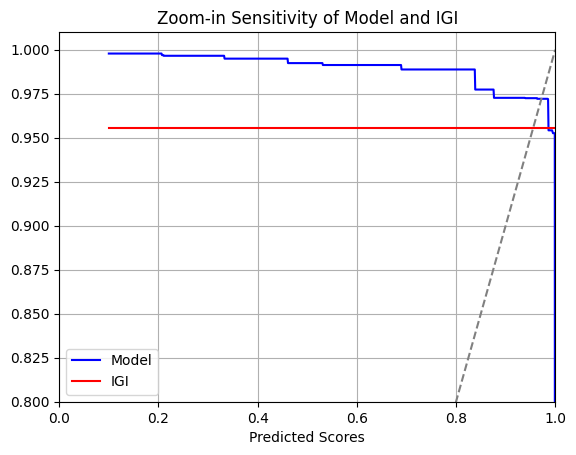

In [44]:
plt.plot(thresholds, sensitivity, color='blue', label='Model')
plt.plot(thresholds, [igi_sensitivity]*len(thresholds), color='red', label='IGI')
plt.plot([0,1], [0,1], color='gray', linestyle='--')
plt.xlabel('Predicted Scores')
plt.xlim([0,1])
plt.ylim([0,1.05])
plt.legend()
plt.grid()
plt.title('Sensitivity of Model and IGI')
plt.show()

plt.plot(thresholds, sensitivity, color='blue', label='Model')
plt.plot(thresholds, [igi_sensitivity]*len(thresholds), color='red', label='IGI')
plt.plot([0,1], [0,1], color='gray', linestyle='--')
plt.xlabel('Predicted Scores')
plt.xlim([0,1])
plt.ylim([0.8, 1.01])
plt.legend()
plt.grid()
plt.title('Zoom-in Sensitivity of Model and IGI')
plt.show()


### Retest set

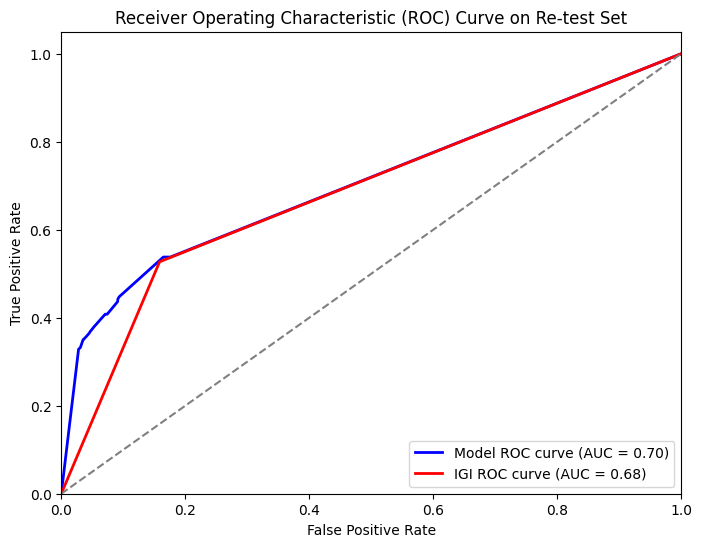

In [45]:
retest_auc = roc_auc_score(retest_pred_df.groundtruth_label, retest_pred_df.outputs)
retest_fpr, retest_tpr, retest_thresholds = roc_curve(retest_pred_df.groundtruth_label, retest_pred_df.outputs)

retest_igi_auc = roc_auc_score(retest_pred_df.groundtruth_label, retest_pred_df.encoded_igi_call)
retest_igi_fpr, retest_igi_tpr, retest_igi_thresholds = roc_curve(retest_pred_df.groundtruth_label, retest_pred_df.encoded_igi_call)

plt.figure(figsize=(8, 6))
plt.plot(retest_fpr, retest_tpr, color='blue', lw=2, label='Model ROC curve (AUC = {:.2f})'.format(retest_auc))
plt.plot(retest_igi_fpr, retest_igi_tpr, color='red', lw=2, label='IGI ROC curve (AUC = {:.2f})'.format(retest_igi_auc))
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve on Re-test Set')
plt.legend(loc='lower right')
plt.show()


In [46]:
tn, fp, fn, tp = confusion_matrix(retest_pred_df.groundtruth_label, retest_pred_df.encoded_igi_call).ravel()

igi_precision = tp/(fp + tp)
igi_sensitivity = tp/(tp + fn)
igi_specificity = tn/(tn + fp)
igi_f1 = 2*tp/(2*tp + fp + fn)
igi_acc = (tp+tn)/(tp+tn+fp+fn)
igi_neg_pred = sum(retest_pred_df.encoded_igi_call == 0)

print('IGI AUC:', retest_igi_auc)
print('True negative, false positive, false negative, true positive:', tn, fp, fn, tp)
print('IGI negative predictions:', igi_neg_pred)
print('IGI precision score:', igi_precision)
print('IGI sensitivity score:', igi_sensitivity)
print('IGI specificity:', igi_specificity)
print('IGI F1:', igi_f1)
print('IGI accuracy:', igi_acc)

IGI AUC: 0.6842498802472164
True negative, false positive, false negative, true positive: 2080 392 131 146
IGI negative predictions: 2211
IGI precision score: 0.27137546468401486
IGI sensitivity score: 0.5270758122743683
IGI specificity: 0.8414239482200647
IGI F1: 0.35828220858895704
IGI accuracy: 0.8097489996362314


In [47]:

# Define the number of true negatives and false negatives for different thresholds
# Replace these values with your actual data
thresholds = np.linspace(0.1, 1, 1000)
specificity, precision, accuracy, sensitivity  = [], [], [], []
for thres in thresholds:
    pred = 1*(retest_pred_df.outputs >= thres)
    tn, fp, fn, tp = confusion_matrix(retest_pred_df.groundtruth_label, pred).ravel()
    
    specificity.append(tn/(tn+fp))
    precision.append(tp/(tp+fp))
    accuracy.append((tp+tn)/len(pred))
    sensitivity.append(tp/(tp+fn))


/tmp/ipykernel_1337620/4274383475.py:10: RuntimeWarning: invalid value encountered in scalar divide
  precision.append(tp/(tp+fp))


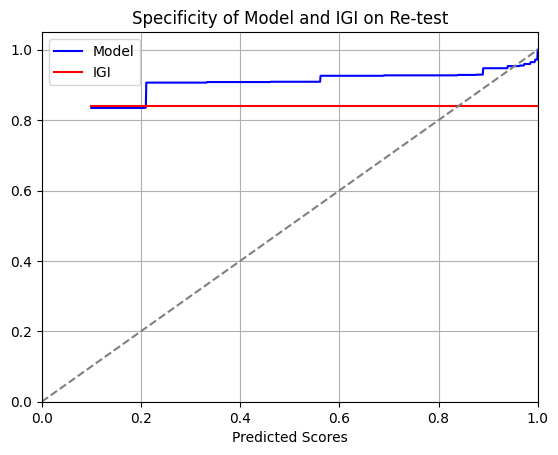

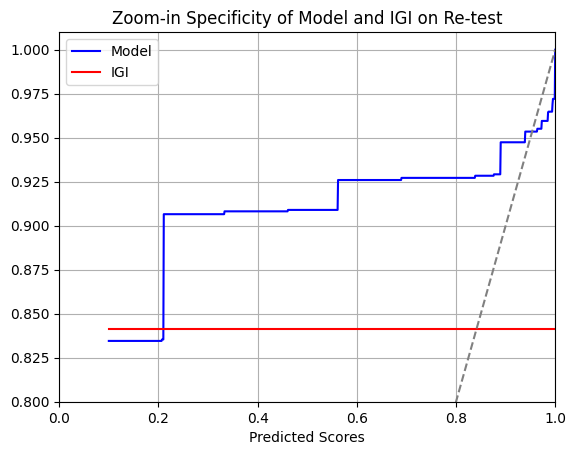

In [48]:
plt.plot(thresholds, specificity, color='blue', label='Model')
plt.plot(thresholds, [igi_specificity]*len(thresholds), color='red', label='IGI')
plt.plot([0,1], [0,1], color='gray', linestyle='--')
plt.xlabel('Predicted Scores')
plt.xlim([0,1])
plt.ylim([0,1.05])
plt.legend()
plt.grid()
plt.title('Specificity of Model and IGI on Re-test')
plt.show()

plt.plot(thresholds, specificity, color='blue', label='Model')
plt.plot(thresholds, [igi_specificity]*len(thresholds), color='red', label='IGI')
plt.plot([0,1], [0,1], color='gray', linestyle='--')
plt.xlabel('Predicted Scores')
plt.xlim([0,1])
plt.ylim([0.8, 1.01])
plt.legend()
plt.grid()
plt.title('Zoom-in Specificity of Model and IGI on Re-test')
plt.show()


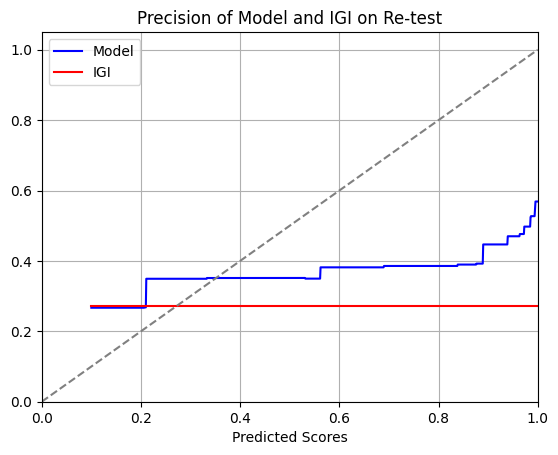

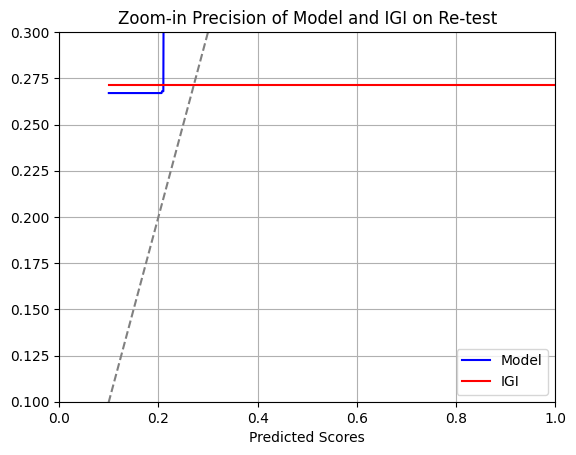

In [49]:
plt.plot(thresholds, precision, color='blue', label='Model')
plt.plot(thresholds, [igi_precision]*len(thresholds), color='red', label='IGI')
plt.plot([0,1], [0,1], color='gray', linestyle='--')
plt.xlabel('Predicted Scores')
plt.xlim([0,1])
plt.ylim([0,1.05])
plt.legend()
plt.grid()
plt.title('Precision of Model and IGI on Re-test')
plt.show()

plt.plot(thresholds, precision, color='blue', label='Model')
plt.plot(thresholds, [igi_precision]*len(thresholds), color='red', label='IGI')
plt.plot([0,1], [0,1], color='gray', linestyle='--')
plt.xlabel('Predicted Scores')
plt.xlim([0,1])
plt.ylim([0.1, 0.3])
plt.legend()
plt.grid()
plt.title('Zoom-in Precision of Model and IGI on Re-test')
plt.show()


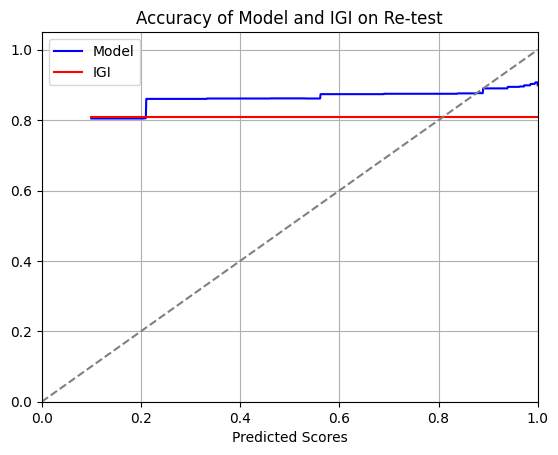

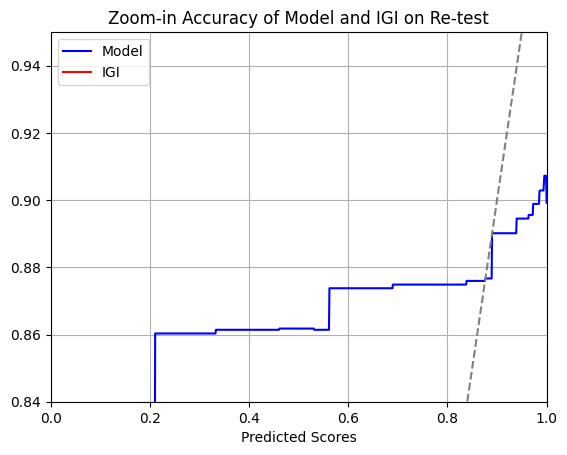

In [50]:
plt.plot(thresholds, accuracy, color='blue', label='Model')
plt.plot(thresholds, [igi_acc]*len(thresholds), color='red', label='IGI')
plt.plot([0,1], [0,1], color='gray', linestyle='--')
plt.xlabel('Predicted Scores')
plt.xlim([0,1])
plt.ylim([0,1.05])
plt.legend()
plt.grid()
plt.title('Accuracy of Model and IGI on Re-test')
plt.show()

plt.plot(thresholds, accuracy, color='blue', label='Model')
plt.plot(thresholds, [igi_acc]*len(thresholds), color='red', label='IGI')
plt.plot([0,1], [0,1], color='gray', linestyle='--')
plt.xlabel('Predicted Scores')
plt.xlim([0,1])
plt.ylim([0.84, 0.95])
plt.legend()
plt.grid()
plt.title('Zoom-in Accuracy of Model and IGI on Re-test')
plt.show()


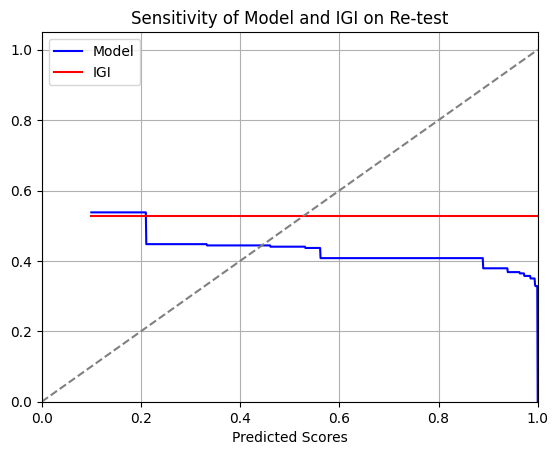

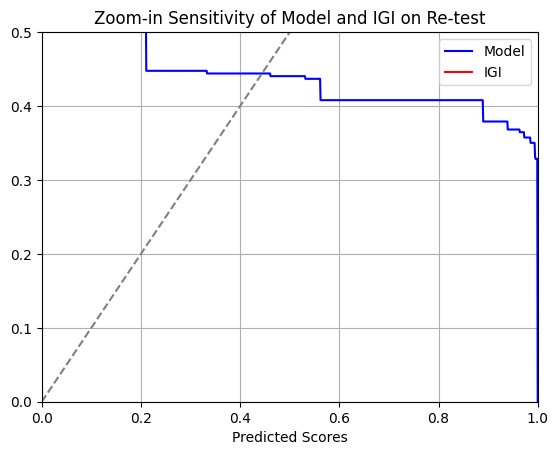

In [51]:
plt.plot(thresholds, sensitivity, color='blue', label='Model')
plt.plot(thresholds, [igi_sensitivity]*len(thresholds), color='red', label='IGI')
plt.plot([0,1], [0,1], color='gray', linestyle='--')
plt.xlabel('Predicted Scores')
plt.xlim([0,1])
plt.ylim([0,1.05])
plt.legend()
plt.grid()
plt.title('Sensitivity of Model and IGI on Re-test')
plt.show()

plt.plot(thresholds, sensitivity, color='blue', label='Model')
plt.plot(thresholds, [igi_sensitivity]*len(thresholds), color='red', label='IGI')
plt.plot([0,1], [0,1], color='gray', linestyle='--')
plt.xlabel('Predicted Scores')
plt.xlim([0,1])
plt.ylim([0, 0.5])
plt.legend()
plt.grid()
plt.title('Zoom-in Sensitivity of Model and IGI on Re-test')
plt.show()


### Sample level
#### Retest

In [54]:
thresholds = np.linspace(0.1, 1, 1000)
neg_preds, tnrs, precisions, recalls = [], [], [], []
for thres in thresholds:
    pred = 1*(test_pred_df.outputs >= thres)
    neg_preds.append(sum(pred == 0))
    tn, fp, fn, tp = confusion_matrix(test_pred_df.groundtruth_label, pred).ravel()
    # tnrs.append(sum((test_pred_df.groundtruth_label == 0) & (test_pred_df.groundtruth_label == pred)))
    # precisions.append(precision_score(test_pred_df.groundtruth_label, pred))
    # recalls.append(recall_score(test_pred_df.groundtruth_label, pred))

# threshold_idx = neg_preds.index(868)
# matched_thres = thresholds[threshold_idx]
matched_thres = 0.9712
matched_pred = 1*(test_pred_df.outputs >= matched_thres)

In [55]:
retest_pred_df['matched_pred'] = 1*(retest_pred_df.outputs >= matched_thres)

In [56]:
retest_sample_level = (retest_pred_df
                       .loc[~retest_pred_df.target.isin(['MS2','RnaseP'])]
                       .groupby(['sample_id','current_sample_result','groundtruth_label'])
                       .matched_pred.mean().reset_index())

retest_sample_level['sample_pred'] = 1*(retest_sample_level['matched_pred'] > 0.5)
retest_sample_level['igi_sample_pred'] = 1*(retest_sample_level['current_sample_result'] == 'Positive')


Text(0.5, 1.0, 'IGI')

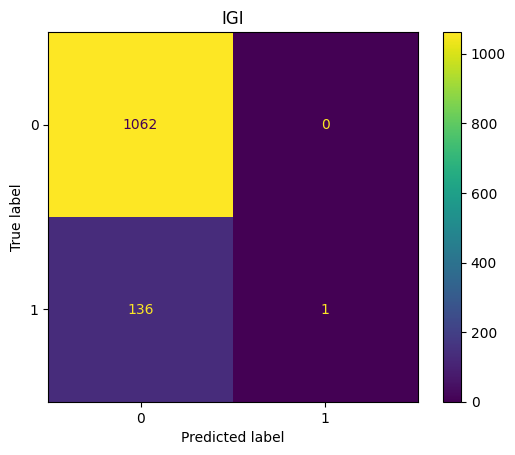

In [57]:
cm = confusion_matrix(retest_sample_level.groundtruth_label, retest_sample_level.igi_sample_pred)
ConfusionMatrixDisplay(cm).plot()
plt.title('IGI')

Text(0.5, 1.0, 'Our model')

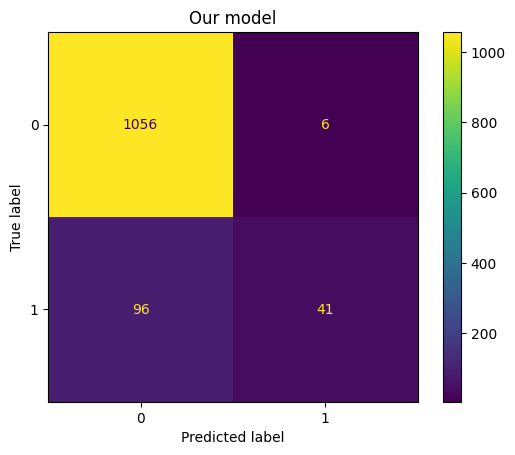

In [58]:
cm = confusion_matrix(retest_sample_level.groundtruth_label, retest_sample_level.sample_pred)
ConfusionMatrixDisplay(cm).plot()
plt.title('Our model')


In [59]:
tn, fp, fn, tp = confusion_matrix(retest_sample_level.groundtruth_label, retest_sample_level.sample_pred).ravel()

precision = tp/(fp + tp)
sensitivity = tp/(tp + fn)
specificity = tn/(tn + fp)
f1 = 2*tp/(2*tp + fp + fn)
acc = (tp+tn)/(tp+tn+fp+fn)
neg_pred = sum(retest_sample_level.sample_pred == 0)
auc = roc_auc_score(retest_sample_level.groundtruth_label, retest_sample_level.matched_pred)

print('Model AUC:', auc)
print('True negative, false positive, false negative, true positive:', tn, fp, fn, tp)
print('Model negative predictions:', neg_pred)
print('Model precision score:', precision)
print('Model sensitivity score:', sensitivity)
print('Model specificity:', specificity)
print('Model F1:', f1)
print('Model accuracy:', acc)

Model AUC: 0.687818741666323
True negative, false positive, false negative, true positive: 1056 6 96 41
Model negative predictions: 1152
Model precision score: 0.8723404255319149
Model sensitivity score: 0.29927007299270075
Model specificity: 0.9943502824858758
Model F1: 0.44565217391304346
Model accuracy: 0.9149291075896581


In [60]:
tn, fp, fn, tp = confusion_matrix(retest_sample_level.groundtruth_label, retest_sample_level.igi_sample_pred).ravel()

igi_precision = tp/(fp + tp)
igi_sensitivity = tp/(tp + fn)
igi_specificity = tn/(tn + fp)
igi_f1 = 2*tp/(2*tp + fp + fn)
igi_acc = (tp+tn)/(tp+tn+fp+fn)
igi_neg_pred = sum(retest_pred_df.encoded_igi_call == 0)
igi_auc = roc_auc_score(retest_sample_level.groundtruth_label, retest_sample_level.igi_sample_pred)

print('IGI AUC:', igi_auc)
print('True negative, false positive, false negative, true positive:', tn, fp, fn, tp)
print('IGI negative predictions:', igi_neg_pred)
print('IGI precision score:', igi_precision)
print('IGI sensitivity score:', igi_sensitivity)
print('IGI specificity:', igi_specificity)
print('IGI F1:', igi_f1)
print('IGI accuracy:', igi_acc)

IGI AUC: 0.5036496350364964
True negative, false positive, false negative, true positive: 1062 0 136 1
IGI negative predictions: 2211
IGI precision score: 1.0
IGI sensitivity score: 0.0072992700729927005
IGI specificity: 1.0
IGI F1: 0.014492753623188406
IGI accuracy: 0.8865721434528774


#### Test set

In [65]:
(test_pred_df
 .loc[~test_pred_df.target.isin(['MS2','RnaseP'])]
 .groupby(['sample_id','current_sample_result','final_patient_result'])
 .curve_idx.nunique().reset_index())

,sample_id,current_sample_result,final_patient_result,curve_idx
0,S136857,Negative,Negative,3
1,S141969,Negative,Negative,3
2,S141970,Negative,Negative,3
3,S143151,Negative,Negative,3
4,S143161,Invalid,ReSample,3
5,S152141,Negative,Negative,3
6,S166395,Negative,Negative,3
7,S181723,Negative,Negative,3
8,S242453,Negative,Negative,3
9,S279563,Negative,Negative,3
